# import library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

# Load Data

In [2]:
df = pd.read_csv('produksi_padi_jabar.csv', delimiter=';')
df.head()

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,bulan,produksi_padi,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,JANUARI,25475,TON GABAH KERING GILING,2018
1,2,32,JAWA BARAT,3201,KABUPATEN BOGOR,FEBRUARI,25290,TON GABAH KERING GILING,2018
2,3,32,JAWA BARAT,3201,KABUPATEN BOGOR,MARET,44928,TON GABAH KERING GILING,2018
3,4,32,JAWA BARAT,3201,KABUPATEN BOGOR,APRIL,39470,TON GABAH KERING GILING,2018
4,5,32,JAWA BARAT,3201,KABUPATEN BOGOR,MEI,36418,TON GABAH KERING GILING,2018


# Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1944 entries, 0 to 1943
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   1944 non-null   int64 
 1   kode_provinsi        1944 non-null   int64 
 2   nama_provinsi        1944 non-null   object
 3   kode_kabupaten_kota  1944 non-null   int64 
 4   nama_kabupaten_kota  1944 non-null   object
 5   bulan                1944 non-null   object
 6   produksi_padi        1944 non-null   int64 
 7   satuan               1944 non-null   object
 8   tahun                1944 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 136.8+ KB


In [4]:
df.describe()

,id,kode_provinsi,kode_kabupaten_kota,produksi_padi,tahun
count,1944.000000,1944.0,1944.000000,1944.000000,1944.000000
mean,972.500000,32.0,3231.333333,28516.742284,2020.500000
std,561.328781,0.0,31.209880,42932.602677,1.708265
min,1.000000,32.0,3201.000000,0.000000,2018.000000
25%,486.750000,32.0,3207.000000,801.500000,2019.000000
50%,972.500000,32.0,3214.000000,13900.500000,2020.500000
75%,1458.250000,32.0,3273.000000,37743.000000,2022.000000
max,1944.000000,32.0,3279.000000,442185.000000,2023.000000


In [5]:
print(df.isnull().sum())

id                     0
kode_provinsi          0
nama_provinsi          0
kode_kabupaten_kota    0
nama_kabupaten_kota    0
bulan                  0
produksi_padi          0
satuan                 0
tahun                  0
dtype: int64


In [6]:
cek_jumlah = df['nama_kabupaten_kota'].value_counts()
print(cek_jumlah)

nama_kabupaten_kota
KABUPATEN BOGOR            72
KABUPATEN SUKABUMI         72
KABUPATEN CIANJUR          72
KABUPATEN BANDUNG          72
KABUPATEN GARUT            72
KABUPATEN TASIKMALAYA      72
KABUPATEN CIAMIS           72
KABUPATEN KUNINGAN         72
KABUPATEN CIREBON          72
KABUPATEN MAJALENGKA       72
KABUPATEN SUMEDANG         72
KABUPATEN INDRAMAYU        72
KABUPATEN SUBANG           72
KABUPATEN PURWAKARTA       72
KABUPATEN KARAWANG         72
KABUPATEN BEKASI           72
KABUPATEN BANDUNG BARAT    72
KABUPATEN PANGANDARAN      72
KOTA BOGOR                 72
KOTA SUKABUMI              72
KOTA BANDUNG               72
KOTA CIREBON               72
KOTA BEKASI                72
KOTA DEPOK                 72
KOTA CIMAHI                72
KOTA TASIKMALAYA           72
KOTA BANJAR                72
Name: count, dtype: int64


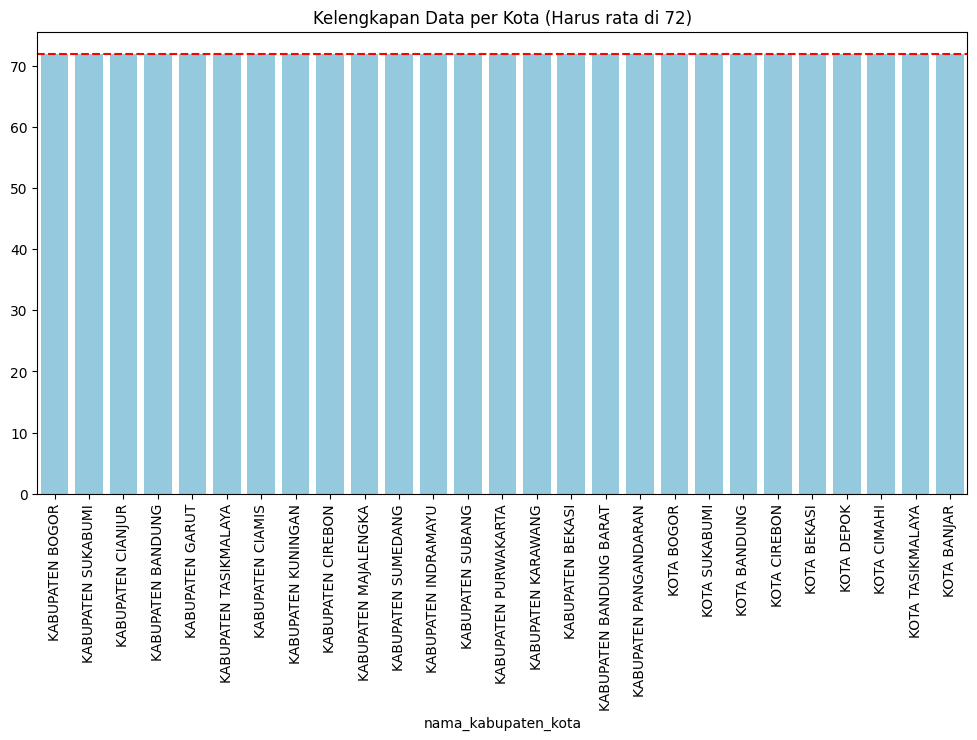

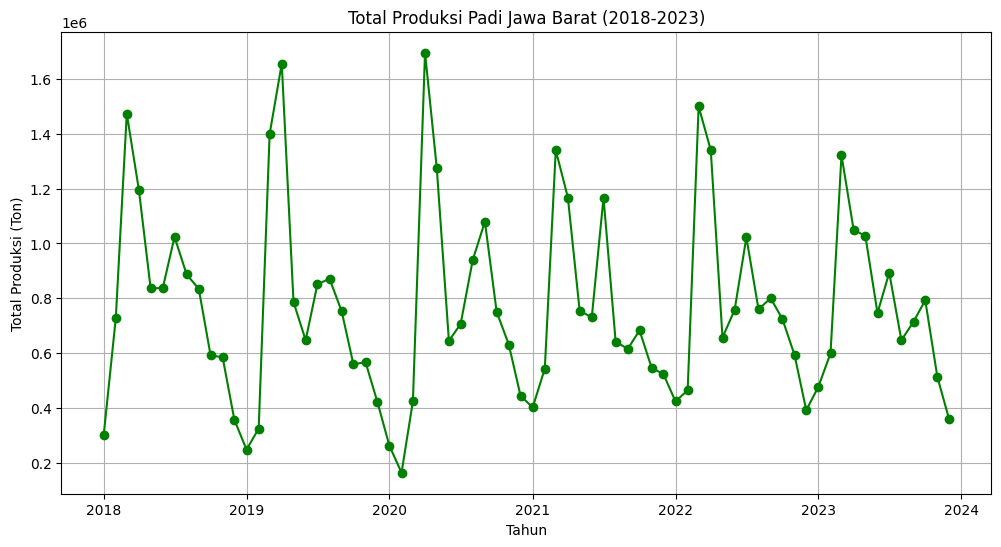

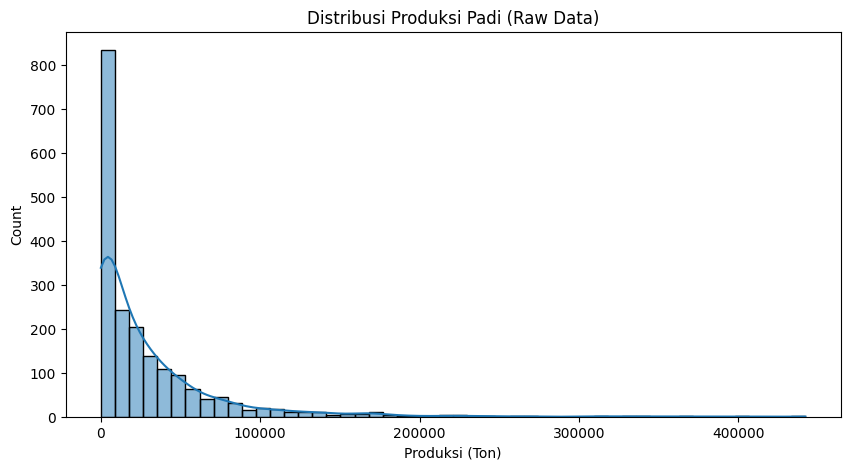

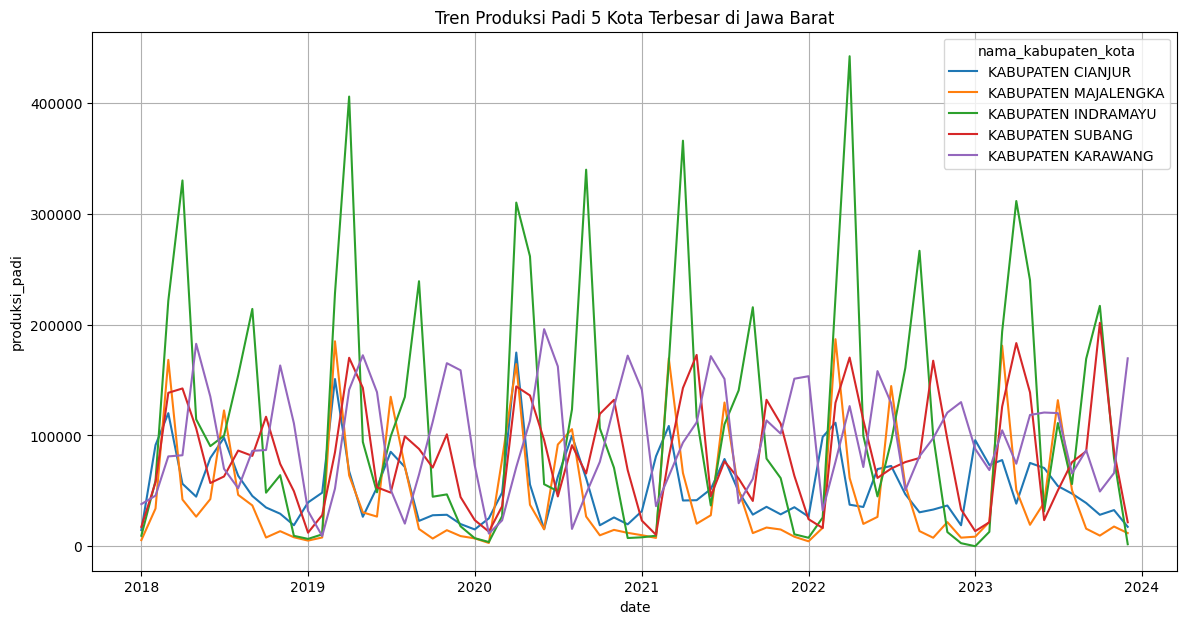

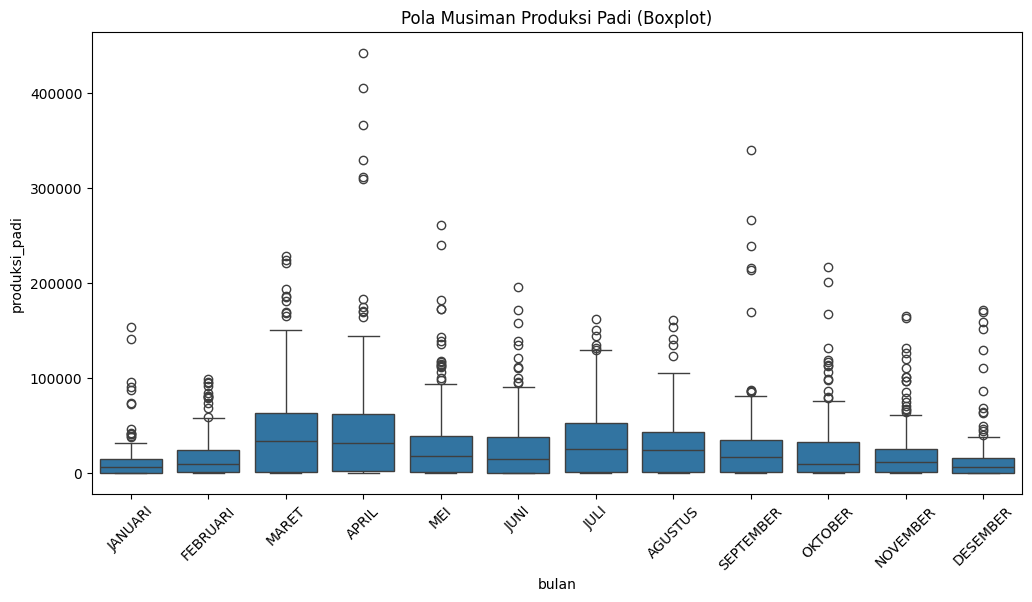

In [7]:
bulan_map = {
    'JANUARI': 1, 'FEBRUARI': 2, 'MARET': 3, 'APRIL': 4, 'MEI': 5, 'JUNI': 6,
    'JULI': 7, 'AGUSTUS': 8, 'SEPTEMBER': 9, 'OKTOBER': 10, 'NOVEMBER': 11, 'DESEMBER': 12
}
df['bulan_num'] = df['bulan'].map(bulan_map)
df['date'] = pd.to_datetime(df['tahun'].astype(str) + '-' + df['bulan_num'].astype(str) + '-01')
df_total = df.groupby('date')['produksi_padi'].sum()

top_5 = df.groupby('nama_kabupaten_kota')['produksi_padi'].sum().nlargest(5).index
df_top5 = df[df['nama_kabupaten_kota'].isin(top_5)]

plt.figure(figsize=(12, 6))
sns.barplot(x=cek_jumlah.index, y=cek_jumlah.values, color='skyblue')
plt.axhline(y=72, color='red', linestyle='--', label='Target (72 Bulan)')
plt.title('Kelengkapan Data per Kota (Harus rata di 72)')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_total.index, df_total.values, color='green', marker='o')
plt.title('Total Produksi Padi Jawa Barat (2018-2023)')
plt.xlabel('Tahun')
plt.ylabel('Total Produksi (Ton)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['produksi_padi'], bins=50, kde=True)
plt.title('Distribusi Produksi Padi (Raw Data)')
plt.xlabel('Produksi (Ton)')
plt.show()

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top5, x='date', y='produksi_padi', hue='nama_kabupaten_kota')
plt.title('Tren Produksi Padi 5 Kota Terbesar di Jawa Barat')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bulan', y='produksi_padi', 
            order=['JANUARI', 'FEBRUARI', 'MARET', 'APRIL', 'MEI', 'JUNI', 
                   'JULI', 'AGUSTUS', 'SEPTEMBER', 'OKTOBER', 'NOVEMBER', 'DESEMBER'])
plt.title('Pola Musiman Produksi Padi (Boxplot)')
plt.xticks(rotation=45)
plt.show()



# Preprocessing

In [8]:
bulan_map = {'JANUARI': 1, 'FEBRUARI': 2, 'MARET': 3, 'APRIL': 4, 'MEI': 5, 'JUNI': 6,
             'JULI': 7, 'AGUSTUS': 8, 'SEPTEMBER': 9, 'OKTOBER': 10, 'NOVEMBER': 11, 'DESEMBER': 12}
df_final = df.copy()
df_final['date'] = pd.to_datetime(df_final['tahun'].astype(str) + '-' + df_final['bulan'].map(bulan_map).astype(str) + '-01')
df_final = df_final[['date', 'nama_kabupaten_kota', 'produksi_padi']].sort_values('date')
df_final.to_csv('df_final.csv', index=False)

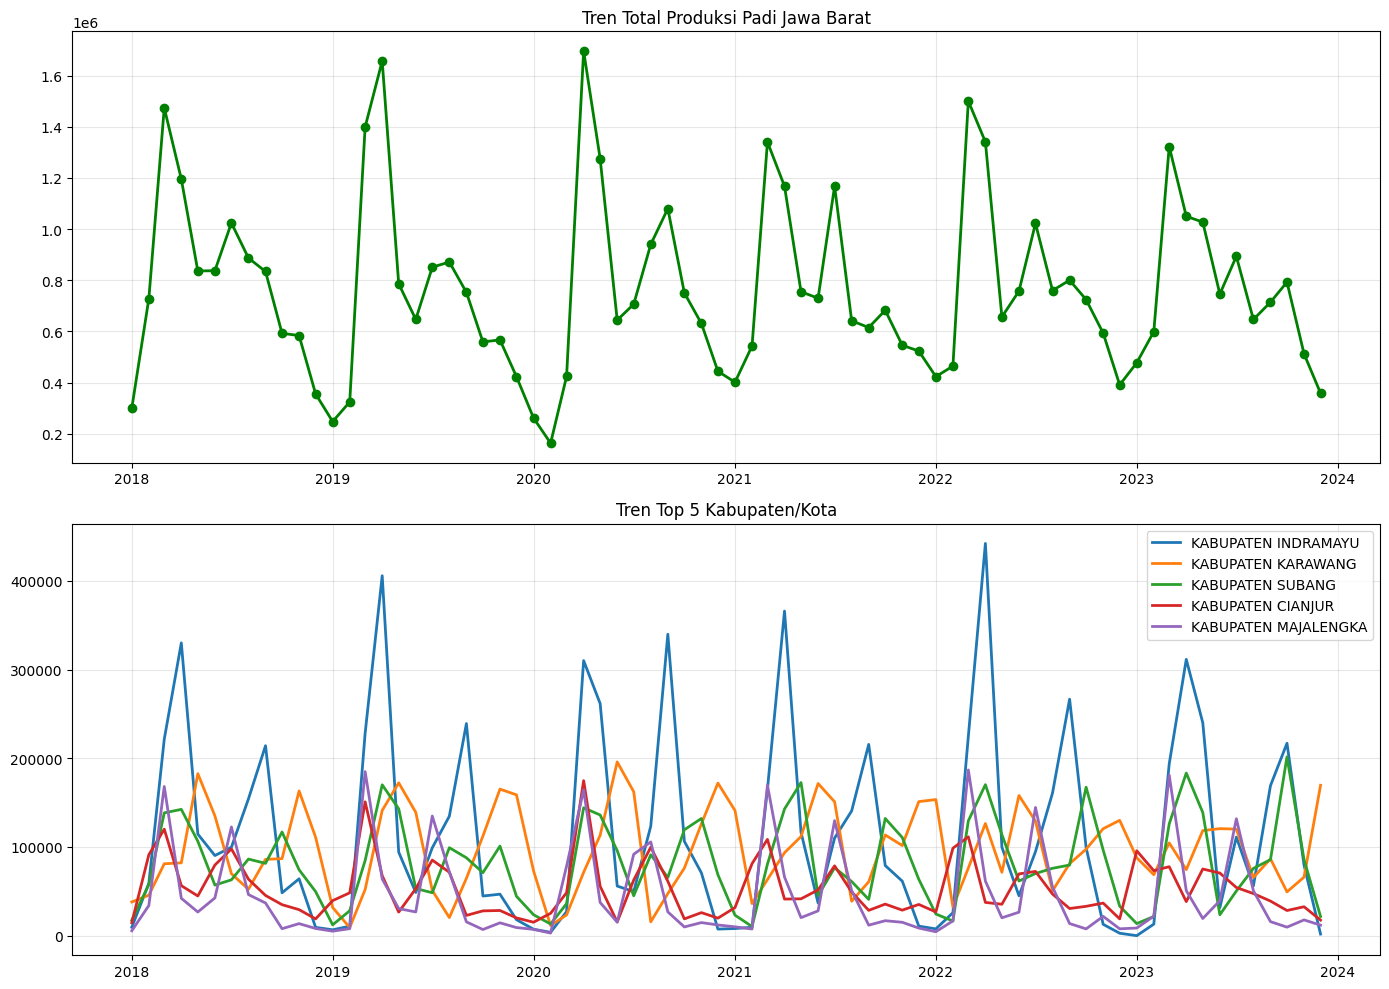

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
df_agg = df_final.groupby('date')['produksi_padi'].sum()
axes[0].plot(df_agg.index, df_agg.values, color='green', linewidth=2, marker='o')
axes[0].set_title('Tren Total Produksi Padi Jawa Barat', fontsize=12)
axes[0].grid(True, alpha=0.3)
top_5_cities = df_final.groupby('nama_kabupaten_kota')['produksi_padi'].sum().nlargest(5).index
for city in top_5_cities:
    city_data = df_final[df_final['nama_kabupaten_kota'] == city]
    axes[1].plot(city_data['date'], city_data['produksi_padi'], label=city, linewidth=2)
axes[1].set_title('Tren Top 5 Kabupaten/Kota', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Modeling

In [16]:
def hitung_mape_kustom(y_true, y_pred, threshold=10):
    """Calculate MAPE excluding values below threshold to filter noise."""
    mask = np.array(y_true) > threshold
    if not mask.sum(): 
        return None
    y_true_filtered = np.array(y_true)[mask]
    y_pred_filtered = np.array(y_pred)[mask]
    return np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_filtered))

def auto_tune_holtwinters(series_data, use_log=False):
    """Find best Holt-Winters configuration by testing 4 combinations."""
    train, test = series_data[:-12], series_data[-12:]
    train_prepared = np.log(train.replace(0, 0.01)) if use_log else train.replace(0, 0.01)
    
    best_mape = float('inf')
    best_config = ""
    
    configs = [
        {'t': 'add', 's': 'add', 'd': False},
        {'t': 'add', 's': 'mul', 'd': False},
        {'t': 'add', 's': 'add', 'd': True},
        {'t': 'mul', 's': 'mul', 'd': True}
    ]
    
    for cfg in configs:
        try:
            model = ExponentialSmoothing(
                train_prepared, 
                trend=cfg['t'], 
                seasonal=cfg['s'],
                damped_trend=cfg['d'], 
                seasonal_periods=12
            ).fit(optimized=True)
            
            forecast = np.exp(model.forecast(len(test))) if use_log else model.forecast(len(test))
            mape = hitung_mape_kustom(test, forecast)
            
            if mape and mape < best_mape:
                best_mape = mape
                best_config = f"T={cfg['t']}, S={cfg['s']}, D={cfg['d']}, Log={use_log}"
                
        except Exception as e:
            continue
            
    return best_mape, best_config

In [17]:
print("Mulai Forecasting...")
results = []

for kota in df_final['nama_kabupaten_kota'].unique():
    # Prepare time series data
    ts = df_final[df_final['nama_kabupaten_kota'] == kota].set_index('date')['produksi_padi'].asfreq('MS').fillna(0)
    
    # Skip cities with low average production
    if ts.mean() < 100:
        continue
    
    # Test both log and non-log transformations
    mape_normal, cfg_normal = auto_tune_holtwinters(ts, use_log=False)
    mape_log, cfg_log = auto_tune_holtwinters(ts, use_log=True)
    
    # Select best result
    best_mape = min(mape_normal, mape_log)
    if best_mape == float('inf'):
        continue
        
    best_config = cfg_log if mape_log < mape_normal else cfg_normal
    results.append({'Kota': kota, 'MAPE': best_mape, 'Config': best_config})

# Create results dataframe
df_hasil = pd.DataFrame(results).sort_values('MAPE')
df_hasil['Akurasi'] = (1 - df_hasil['MAPE']) * 100

print(f"\n=== TOP {min(10, len(df_hasil))} HASIL FORECASTING ===")
print(df_hasil[['Kota', 'MAPE', 'Akurasi']].head(10))

Mulai Forecasting...


C:\Users\Pongo\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Pongo\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Pongo\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Pongo\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Pongo\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Pongo\AppData\Roaming\Pyth


=== TOP 10 HASIL FORECASTING ===
                     Kota      MAPE    Akurasi
3       KABUPATEN BANDUNG  0.098180  90.182001
14     KABUPATEN KUNINGAN  0.180838  81.916173
9   KABUPATEN TASIKMALAYA  0.231698  76.830235
15   KABUPATEN MAJALENGKA  0.252429  74.757050
2        KABUPATEN BEKASI  0.262776  73.722351
18      KABUPATEN CIREBON  0.282088  71.791169
12       KABUPATEN CIAMIS  0.297567  70.243254
5         KABUPATEN GARUT  0.307808  69.219249
17      KABUPATEN CIANJUR  0.313957  68.604260
13     KABUPATEN SUMEDANG  0.347147  65.285329


In [18]:
def get_future_forecast(ts):
    mape_n, cfg_n = auto_tune_holtwinters(ts, use_log=False)
    mape_l, cfg_l = auto_tune_holtwinters(ts, use_log=True)
    use_log = mape_l < mape_n
    cfg = cfg_l if use_log else cfg_n
    parts = cfg.split(', ')
    trend, seasonal = parts[0].split('=')[1], parts[1].split('=')[1]
    damped = 'true' in parts[2].lower()
    ts = ts.replace(0, 0.01)
    ts_model = np.log(ts) if use_log else ts
    model = ExponentialSmoothing(ts_model, trend=trend, seasonal=seasonal, damped_trend=damped, seasonal_periods=12).fit(optimized=True)
    forecast = np.exp(model.forecast(12)) if use_log else model.forecast(12)
    return forecast, use_log, (mape_l if use_log else mape_n), model

target_kota = 'KABUPATEN BANDUNG'
ts_kota = df_final[df_final['nama_kabupaten_kota'] == target_kota].set_index('date')['produksi_padi'].asfreq('MS').fillna(0)
forecast_2024, use_log, error_val, model = get_future_forecast(ts_kota)
forecast_2024[forecast_2024 < 0] = 0

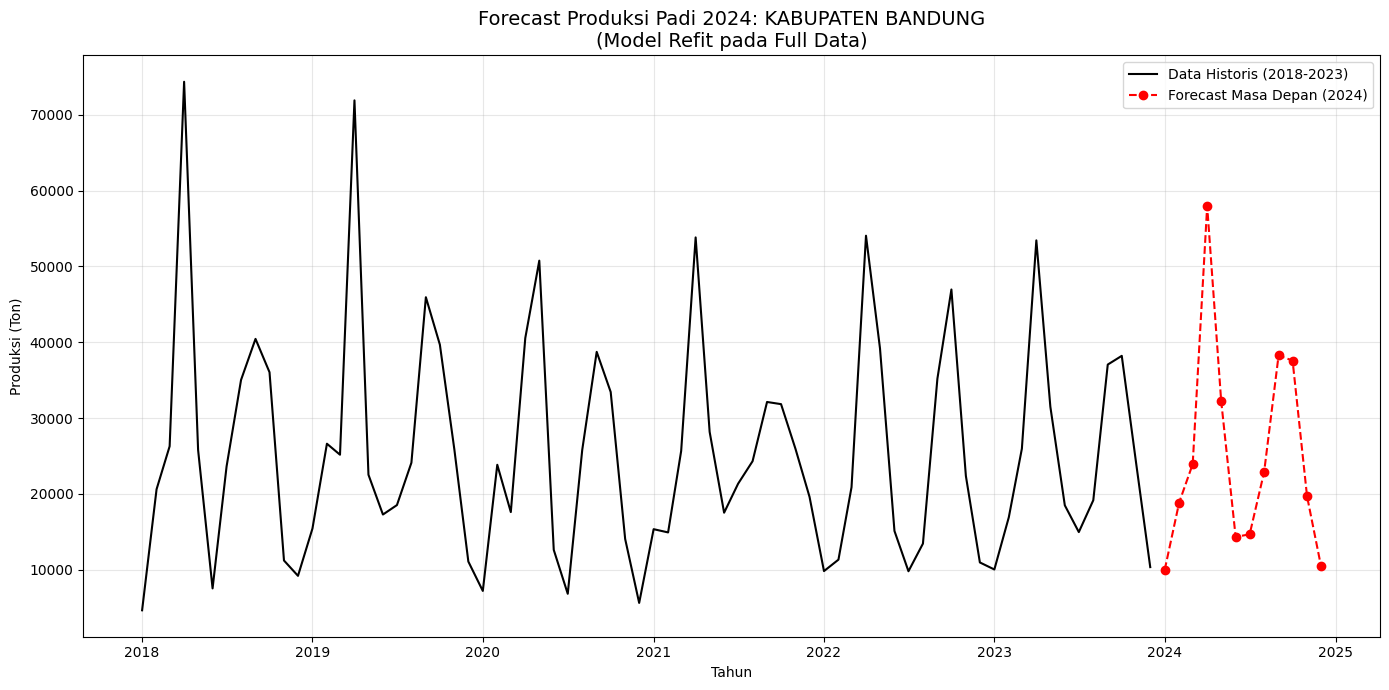

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(ts_kota.index, ts_kota.values, label='Data Historis (2018-2023)', color='black')
plt.plot(forecast_2024.index, forecast_2024.values, label='Forecast Masa Depan (2024)', color='red', linestyle='--', marker='o')
plt.title(f'Forecast Produksi Padi 2024: {target_kota}\n(Model Refit pada Full Data)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Produksi (Ton)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Simpan model ke file .pkl untuk deployment Streamlit
with open('model_forecast_padi.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model telah disimpan sebagai 'model_forecast_padi.pkl'")

Model telah disimpan sebagai 'model_forecast_padi.pkl'


In [21]:
b_low, b_high = ts_kota.quantile(0.25), ts_kota.quantile(0.75)
def categorize(val, bl, bh):
    if val <= 10: return "Paceklik"
    elif val < bl: return "Panen Rendah"
    elif val < bh: return "Panen Sedang"
    elif val > (bh * 1.5): return "Panen Raya Ekstrem"
    else: return "Panen Raya"

df_pred = pd.DataFrame({'Bulan': forecast_2024.index.strftime('%B %Y'),
                         'Prediksi (Ton)': forecast_2024.values.round(0).astype(int)})
df_pred['Kategori'] = df_pred['Prediksi (Ton)'].apply(lambda x: categorize(x, b_low, b_high))
mae = mean_absolute_error(ts_kota[-12:], forecast_2024)
rmse = np.sqrt(mean_squared_error(ts_kota[-12:], forecast_2024))

print(f"\n=== PREDIKSI 2024: {target_kota} ===")
print(df_pred.to_string(index=False))
print(f"\nAkurasi Model - MAPE: {(1-error_val)*100:.2f}% | MAE: {mae:,.0f} Ton | RMSE: {rmse:,.0f} Ton")


=== PREDIKSI 2024: KABUPATEN BANDUNG ===
         Bulan  Prediksi (Ton)           Kategori
  January 2024            9993       Panen Rendah
 February 2024           18874       Panen Sedang
    March 2024           23941       Panen Sedang
    April 2024           57964 Panen Raya Ekstrem
      May 2024           32269       Panen Sedang
     June 2024           14349       Panen Rendah
     July 2024           14677       Panen Rendah
   August 2024           22883       Panen Sedang
September 2024           38259         Panen Raya
  October 2024           37586         Panen Raya
 November 2024           19694       Panen Sedang
 December 2024           10462       Panen Rendah

Akurasi Model - MAPE: 90.18% | MAE: 1,974 Ton | RMSE: 2,586 Ton
